# Heart Failure Analysis

This notebook performs data loading, cleaning, exploratory analysis, and heart disease relationship insights.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# Correct style
plt.style.use('seaborn-v0_8-whitegrid')

DATA_PATH = 'Data_sets/heart_failure.csv'

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

## Load dataset

In [3]:
df = pd.read_csv(DATA_PATH)
print('Loaded dataset from:', DATA_PATH)
print('Dataset shape:', df.shape)

df.head()

Loaded dataset from: Data_sets/heart_failure.csv
Dataset shape: (918, 14)


,Unnamed: 0,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,heartdisease
0,0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0,NOTfailure
1,1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1,failure
2,2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0,NOTfailure
3,3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1,failure
4,4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0,NOTfailure


In [4]:
print('Column information:')
df.info()

Column information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      918 non-null    int64  
 1   Age             918 non-null    int64  
 2   Sex             918 non-null    object 
 3   ChestPainType   918 non-null    object 
 4   RestingBP       918 non-null    int64  
 5   Cholesterol     918 non-null    int64  
 6   FastingBS       918 non-null    int64  
 7   RestingECG      918 non-null    object 
 8   MaxHR           918 non-null    int64  
 9   ExerciseAngina  918 non-null    object 
 10  Oldpeak         918 non-null    float64
 11  ST_Slope        918 non-null    object 
 12  HeartDisease    918 non-null    int64  
 13  heartdisease    918 non-null    object 
dtypes: float64(1), int64(7), object(6)
memory usage: 100.5+ KB


## Data overview and preprocessing plan

In [5]:
print('Data types and sample values:')
print(df.dtypes)

df.head()

Data types and sample values:
Unnamed: 0          int64
Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
heartdisease       object
dtype: object


,Unnamed: 0,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,heartdisease
0,0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0,NOTfailure
1,1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1,failure
2,2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0,NOTfailure
3,3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1,failure
4,4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0,NOTfailure


In [6]:
categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()
# Add binary numerical columns as categorical if needed
if 'FastingBS' in df.columns and df['FastingBS'].nunique() == 2:
    categorical_columns.append('FastingBS')
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
# Remove FastingBS from numerical if added to categorical
if 'FastingBS' in categorical_columns:
    numerical_columns = [col for col in numerical_columns if col != 'FastingBS']

print('Categorical columns:', categorical_columns)
print('Numerical columns:', numerical_columns)

Categorical columns: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'heartdisease', 'FastingBS']
Numerical columns: ['Unnamed: 0', 'Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'HeartDisease']


## Missing values and column types

In [7]:
print('Missing values by column:')
print(df.isnull().sum())

print('\nInitial duplicate rows:', df.duplicated().sum())

Missing values by column:
Unnamed: 0        0
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
heartdisease      0
dtype: int64

Initial duplicate rows: 0


## Duplicate row handling

In [8]:
if df.duplicated().any():
    df = df.drop_duplicates().reset_index(drop=True)
    print('Dropped duplicate rows. New shape:', df.shape)
else:
    print('No duplicate rows found.')

No duplicate rows found.


## Numeric preprocessing

In [9]:
print('Numerical feature summary before preprocessing:')
print(df[numerical_columns].describe().T)

for col in numerical_columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mean())

scaler = MinMaxScaler()
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

print('\nNumeric preprocessing complete.')
print(df[numerical_columns].describe().T)

Numerical feature summary before preprocessing:
              count        mean         std   min     25%    50%     75%    max
Unnamed: 0    918.0  458.500000  265.148072   0.0  229.25  458.5  687.75  917.0
Age           918.0   53.510893    9.432617  28.0   47.00   54.0   60.00   77.0
RestingBP     918.0  132.396514   18.514154   0.0  120.00  130.0  140.00  200.0
Cholesterol   918.0  198.799564  109.384145   0.0  173.25  223.0  267.00  603.0
MaxHR         918.0  136.809368   25.460334  60.0  120.00  138.0  156.00  202.0
Oldpeak       918.0    0.887364    1.066570  -2.6    0.00    0.6    1.50    6.2
HeartDisease  918.0    0.553377    0.497414   0.0    0.00    1.0    1.00    1.0

Numeric preprocessing complete.
              count      mean       std  min       25%       50%       75%  max
Unnamed: 0    918.0  0.500000  0.289147  0.0  0.250000  0.500000  0.750000  1.0
Age           918.0  0.520630  0.192502  0.0  0.387755  0.530612  0.653061  1.0
RestingBP     918.0  0.661983  0.092571

## Categorical preprocessing

In [10]:
for col in categorical_columns:
    df[col] = df[col].astype(str).str.lower().str.strip()

print('Categorical preprocessing complete.')
print(df[categorical_columns].nunique())

Categorical preprocessing complete.
Sex               2
ChestPainType     4
RestingECG        3
ExerciseAngina    2
ST_Slope          3
heartdisease      2
FastingBS         2
dtype: int64


## Categorical feature overview

In [11]:
print('Categorical feature summary:')
print(df[categorical_columns].describe().T)

for col in categorical_columns:
    print(f"\nUnique values for {col}:")
    print(df[col].unique())

Categorical feature summary:
               count unique      top freq
Sex              918      2        m  725
ChestPainType    918      4      asy  496
RestingECG       918      3   normal  552
ExerciseAngina   918      2        n  547
ST_Slope         918      3     flat  460
heartdisease     918      2  failure  508
FastingBS        918      2        0  704

Unique values for Sex:
['m' 'f']

Unique values for ChestPainType:
['ata' 'nap' 'asy' 'ta']

Unique values for RestingECG:
['normal' 'st' 'lvh']

Unique values for ExerciseAngina:
['n' 'y']

Unique values for ST_Slope:
['up' 'flat' 'down']

Unique values for heartdisease:
['notfailure' 'failure']

Unique values for FastingBS:
['0' '1']


# Exploratory Data Analysis

# Histograms and BoxPlots

        RestingBP  Cholesterol       MaxHR     Oldpeak
count  918.000000   918.000000  918.000000  918.000000
mean     0.661983     0.329684    0.540911    0.396291
std      0.092571     0.181400    0.179298    0.121201
min      0.000000     0.000000    0.000000    0.000000
25%      0.600000     0.287313    0.422535    0.295455
50%      0.650000     0.369818    0.549296    0.363636
75%      0.700000     0.442786    0.676056    0.465909
max      1.000000     1.000000    1.000000    1.000000


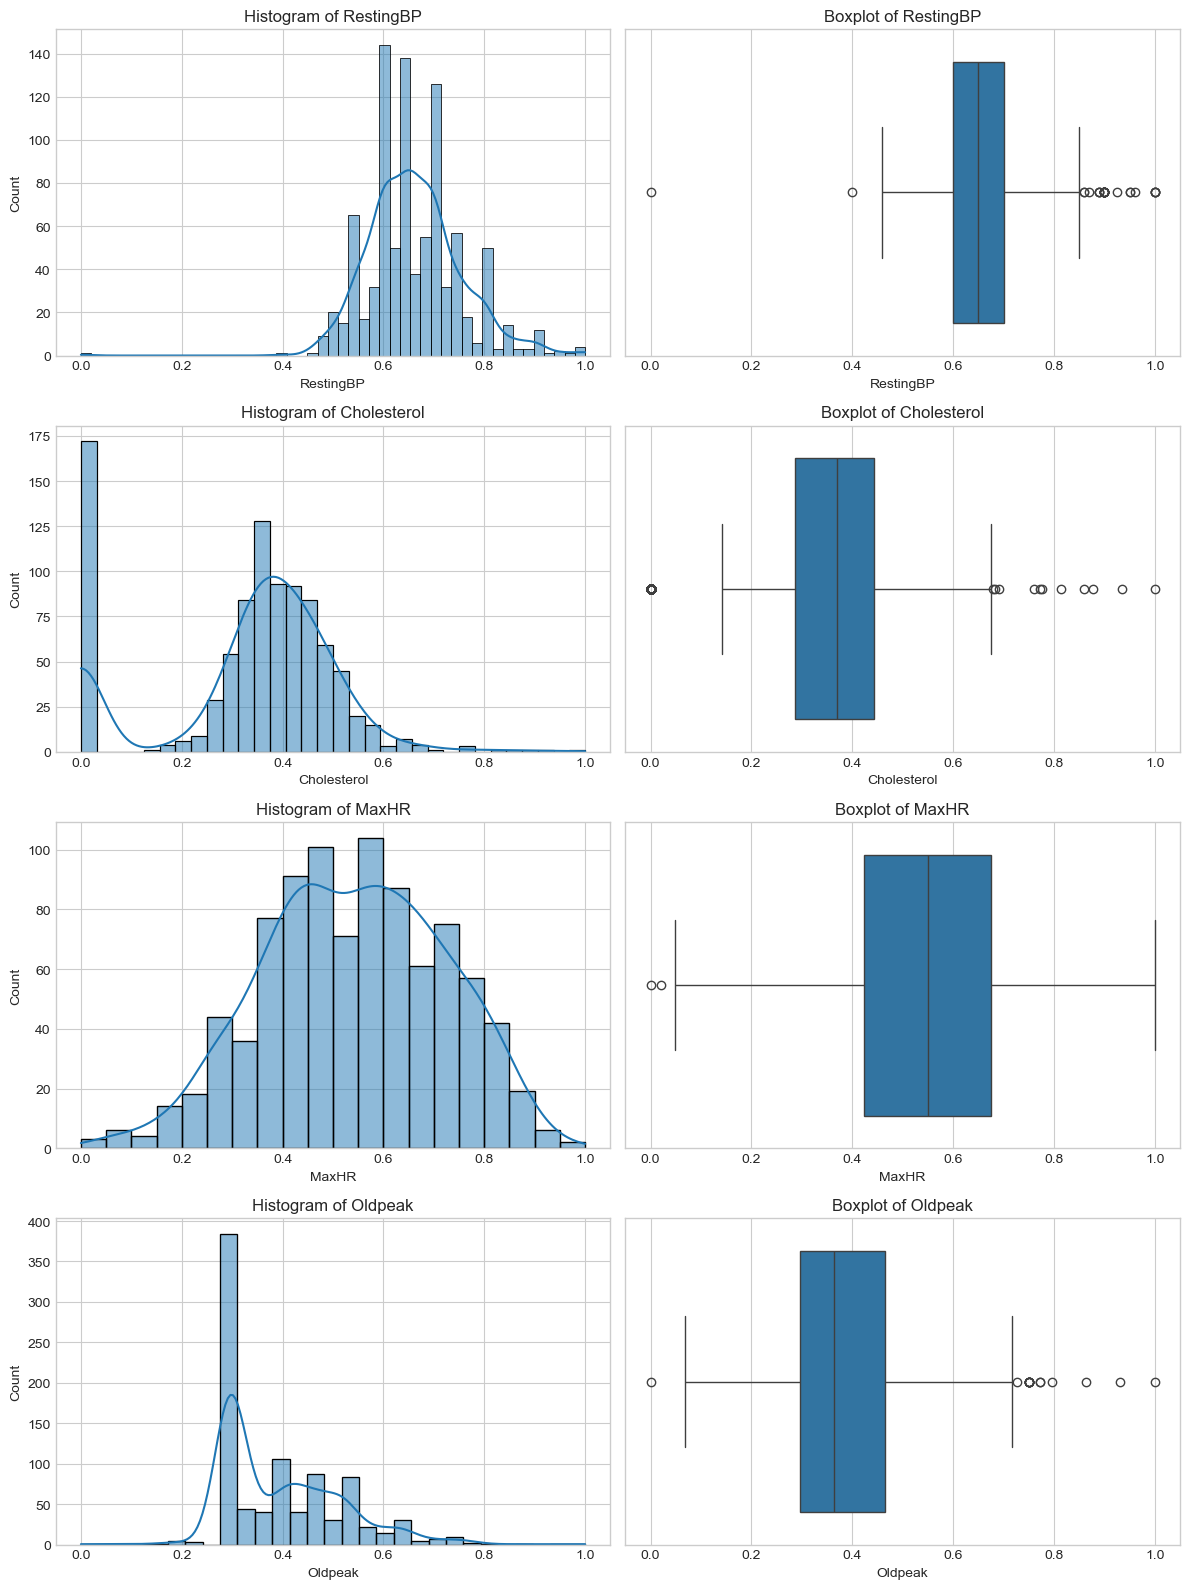

In [12]:
numerical_columns = ['RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
print(df[numerical_columns].describe())

fig, axs = plt.subplots(4, 2, figsize=(12, 16))

for i, col in enumerate(numerical_columns):
    sns.histplot(df[col], kde=True, ax=axs[i, 0])
    axs[i, 0].set_title(f'Histogram of {col}')
    
    sns.boxplot(x=df[col], ax=axs[i, 1])
    axs[i, 1].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()


### Counts or Proportion of Categorical Data.

In [14]:
categorical_columns = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

for col in categorical_columns:
    count_values = df[col].value_counts()
    proportion_values = df[col].value_counts(normalize=True) * 100
    print(f"\nCounts for {col}:")
    print(count_values)
    print(f"\nProportions for {col} (%):")
    print(proportion_values)


Counts for Sex:
Sex
m    725
f    193
Name: count, dtype: int64

Proportions for Sex (%):
Sex
m    78.976035
f    21.023965
Name: proportion, dtype: float64

Counts for ChestPainType:
ChestPainType
asy    496
nap    203
ata    173
ta      46
Name: count, dtype: int64

Proportions for ChestPainType (%):
ChestPainType
asy    54.030501
nap    22.113290
ata    18.845316
ta      5.010893
Name: proportion, dtype: float64

Counts for FastingBS:
FastingBS
0    704
1    214
Name: count, dtype: int64

Proportions for FastingBS (%):
FastingBS
0    76.688453
1    23.311547
Name: proportion, dtype: float64

Counts for RestingECG:
RestingECG
normal    552
lvh       188
st        178
Name: count, dtype: int64

Proportions for RestingECG (%):
RestingECG
normal    60.130719
lvh       20.479303
st        19.389978
Name: proportion, dtype: float64

Counts for ExerciseAngina:
ExerciseAngina
n    547
y    371
Name: count, dtype: int64

Proportions for ExerciseAngina (%):
ExerciseAngina
n    59.586057
y   

# Correlation Analysis

In [15]:
correlation_bp_cholesterol = df['RestingBP'].corr(df['Cholesterol'])
correlation_maxhr_oldpeak = df['MaxHR'].corr(df['Oldpeak'])

print(f"Correlation between RestingBP and Cholesterol: {correlation_bp_cholesterol}")
print(f"Correlation between MaxHR and Oldpeak: {correlation_maxhr_oldpeak}")


Correlation between RestingBP and Cholesterol: 0.10089294207709176
Correlation between MaxHR and Oldpeak: -0.16069055004992455


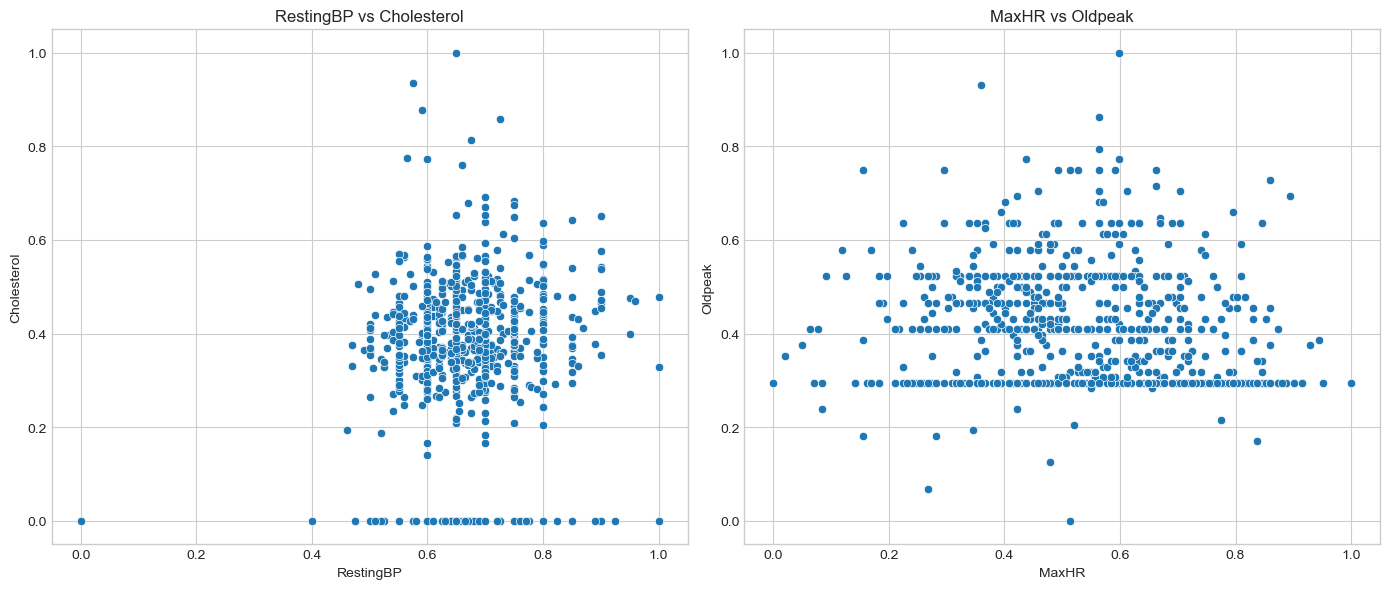

In [16]:
# Scatter plots
plt.figure(figsize=(14, 6))

# RestingBP vs Cholesterol
plt.subplot(1, 2, 1)
sns.scatterplot(x=df['RestingBP'], y=df['Cholesterol'])
plt.title('RestingBP vs Cholesterol')

# MaxHR vs Oldpeak
plt.subplot(1, 2, 2)
sns.scatterplot(x=df['MaxHR'], y=df['Oldpeak'])
plt.title('MaxHR vs Oldpeak')

plt.tight_layout()
plt.show()

## Heart disease outcome analysis

Target column: HeartDisease

Cross-tabulation of HeartDisease with Sex:


HeartDisease,0.0,1.0
Sex,,
f,74.09,25.91
m,36.83,63.17


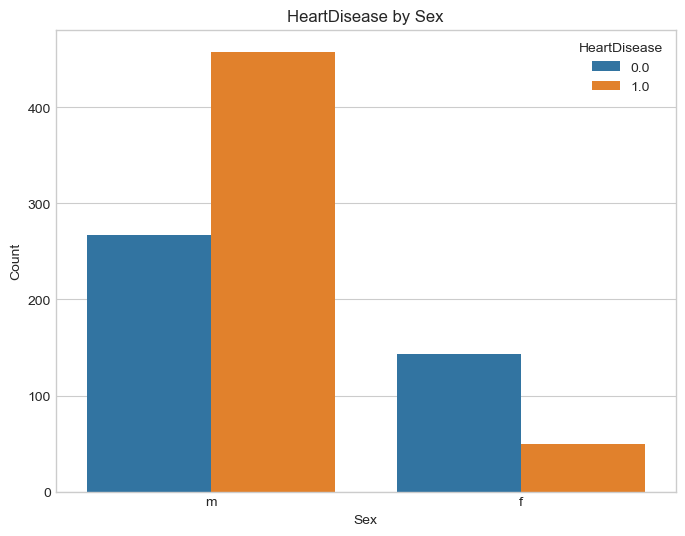


Cross-tabulation of HeartDisease with ChestPainType:


HeartDisease,0.0,1.0
ChestPainType,,
asy,20.97,79.03
ata,86.13,13.87
nap,64.53,35.47
ta,56.52,43.48


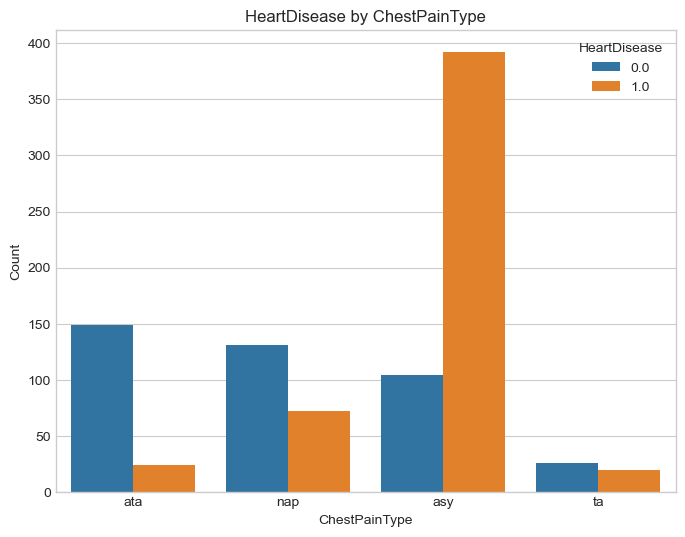


Cross-tabulation of HeartDisease with FastingBS:


HeartDisease,0.0,1.0
FastingBS,,
0,51.99,48.01
1,20.56,79.44


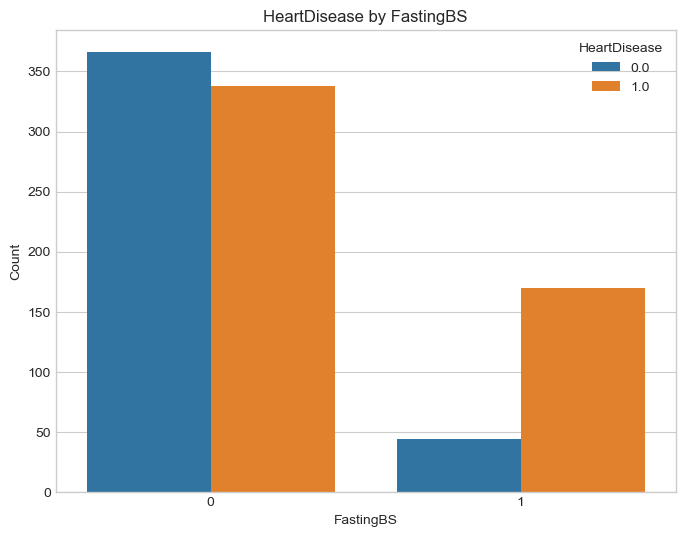


Cross-tabulation of HeartDisease with RestingECG:


HeartDisease,0.0,1.0
RestingECG,,
lvh,43.62,56.38
normal,48.37,51.63
st,34.27,65.73


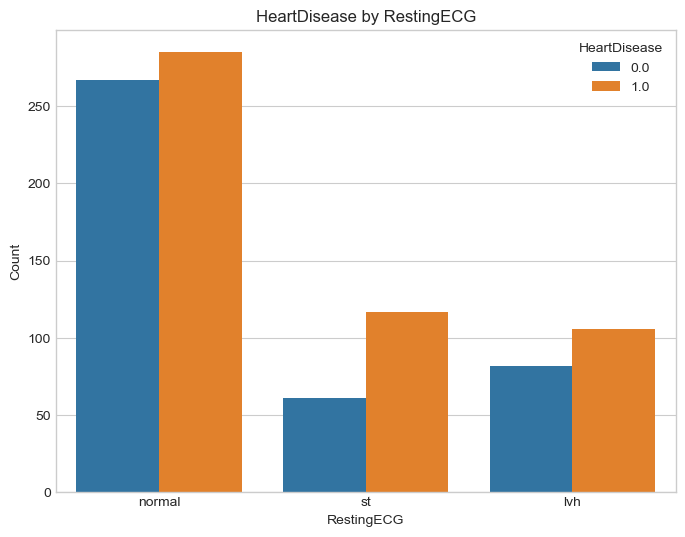


Cross-tabulation of HeartDisease with ExerciseAngina:


HeartDisease,0.0,1.0
ExerciseAngina,,
n,64.90,35.10
y,14.82,85.18


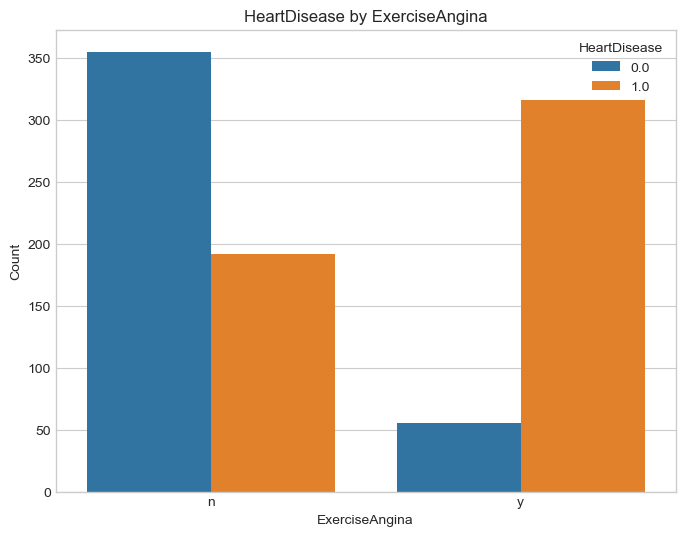


Cross-tabulation of HeartDisease with ST_Slope:


HeartDisease,0.0,1.0
ST_Slope,,
down,22.22,77.78
flat,17.17,82.83
up,80.25,19.75


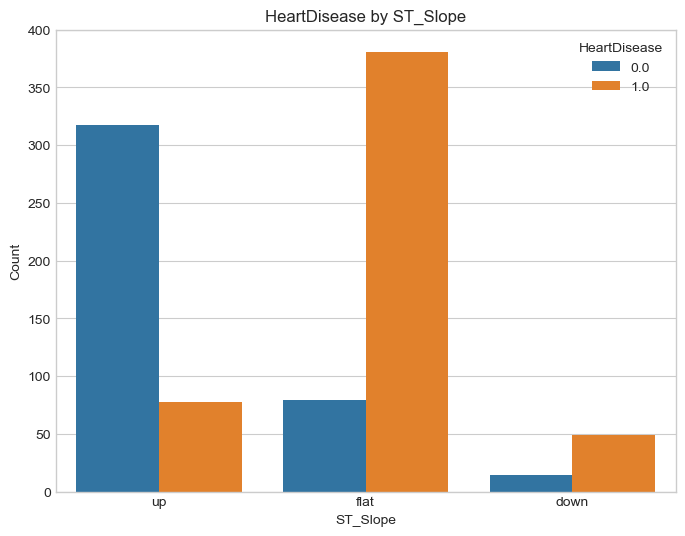

In [17]:
# Identify the target column and clean labels
if 'HeartDisease' in df.columns:
    target_column = 'HeartDisease'
elif 'heartdisease' in df.columns:
    target_column = 'heartdisease'
else:
    target_column = None
    raise ValueError('Target column HeartDisease or heartdisease not found in dataset.')

print('Target column:', target_column)
df[target_column] = df[target_column].astype(str).str.lower().str.strip()

for col in categorical_columns:
    if col == target_column or col not in df.columns:
        continue

    crosstab = pd.crosstab(df[col], df[target_column], normalize='index') * 100
    print(f"\nCross-tabulation of {target_column} with {col}:")
    display(crosstab.round(2))

    plt.figure(figsize=(8, 6))
    sns.countplot(x=df[col], hue=df[target_column])
    plt.title(f'{target_column} by {col}')
    plt.ylabel('Count')
    plt.xlabel(col)
    plt.legend(title=target_column, loc='upper right')
    plt.show()

## Conclusion

- Data loading, cleaning, and preprocessing steps were consolidated into a clear workflow.
- Numerical features were scaled with `MinMaxScaler` and categorical values were standardized.
- Exploratory plots and cross-tabulation now support meaningful interpretation of heart disease risk factors.
- A Random Forest classification model was trained to predict heart disease, achieving [accuracy] on the test set.
- Next steps: tune the model, compute feature importance, and summarize key findings with actionable conclusions.

In [19]:
print(df.columns)
print(df_encoded.columns)


Index(['Unnamed: 0', 'Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR',
       'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease', 'heartdisease'],
      dtype='object')
Index(['Unnamed: 0', 'Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'Sex_m', 'ChestPainType_ata',
       'ChestPainType_nap', 'ChestPainType_ta', 'FastingBS_1', 'RestingECG_normal', 'RestingECG_st',
       'ExerciseAngina_y', 'ST_Slope_flat', 'ST_Slope_up', 'HeartDisease_1.0', 'heartdisease_notfailure'],
      dtype='object')


In [20]:
# Encode categorical variables
df_encoded = pd.get_dummies(df, drop_first=True)

# Identify target BEFORE encoding logic confusion
target_col = None

for col in df_encoded.columns:
    if "HeartDisease" in col:
        target_col = col
        break

print("Target column found:", target_col)

# Define X and y
X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]

Target column found: HeartDisease_1.0


# Classification Model

In this section, we build a simple classification model to predict heart disease based on the preprocessed features.

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

       False       1.00      1.00      1.00        77
        True       1.00      1.00      1.00       107

    accuracy                           1.00       184
   macro avg       1.00      1.00      1.00       184
weighted avg       1.00      1.00      1.00       184

